<a href="https://colab.research.google.com/github/victor22-gif/victor-career-website/blob/main/E-commerce/E_commerce_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creating sample e-commerce data...

Sample of purchase data:
   UserID        Product  Rating
0  User_1        Monitor       3
1  User_1     Power Bank       5
2  User_1         Laptop       2
3  User_1  Phone Charger       4
4  User_1       Speakers       2

Creating user-product matrix...

Getting recommendations for User_1...

Top recommended products:
Webcam: Score = 3.54
Mouse: Score = 3.49
USB Drive: Score = 3.41

Basic Statistics:
Number of users: 5
Number of products: 10
Average rating: 3.10


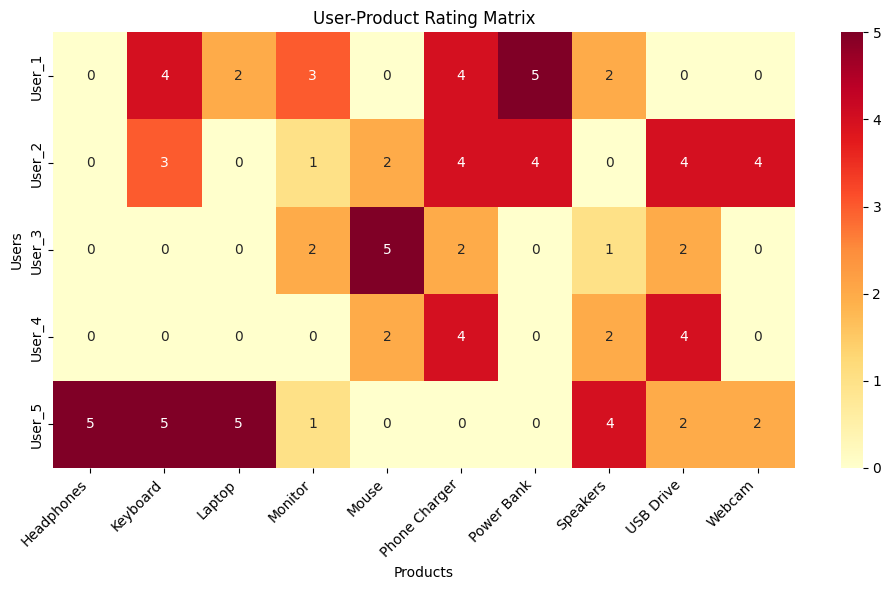

In [ ]:
# Simple E-commerce Product Recommendation System
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Create sample e-commerce data
def create_sample_data():
    """Create a sample e-commerce dataset"""
    # Create sample users and products
    users = range(1, 6)  # 5 users
    products = [
        'Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Headphones',
        'Speakers', 'Webcam', 'USB Drive', 'Phone Charger', 'Power Bank'
    ]

    # Create purchase data
    data = []
    np.random.seed(42)  # For reproducible results

    for user in users:
        # Each user buys 3-7 products
        n_purchases = np.random.randint(3, 8)
        # Random products for each user
        user_products = np.random.choice(products, n_purchases, replace=False)

        for product in user_products:
            # Rating is 1-5 stars
            rating = np.random.randint(1, 6)
            data.append([f'User_{user}', product, rating])

    return pd.DataFrame(data, columns=['UserID', 'Product', 'Rating'])

# Create user-product matrix
def create_user_product_matrix(df):
    """Convert purchase data to user-product matrix"""
    return df.pivot_table(
        index='UserID',
        columns='Product',
        values='Rating',
        fill_value=0
    )

# Get product recommendations
def get_recommendations(user_id, user_product_matrix, n_recommendations=3):
    """Get product recommendations for a user"""
    # Calculate product similarity
    product_similarity = cosine_similarity(user_product_matrix.T)
    product_similarity_df = pd.DataFrame(
        product_similarity,
        index=user_product_matrix.columns,
        columns=user_product_matrix.columns
    )

    # Get user's purchased products
    user_purchases = user_product_matrix.loc[user_id]
    purchased_products = user_purchases[user_purchases > 0].index

    # Get products user hasn't purchased
    not_purchased = user_purchases[user_purchases == 0].index

    # Calculate recommendation scores
    recommendations = {}
    for product in not_purchased:
        # Find similar products the user has purchased
        prod_similarities = product_similarity_df.loc[product, purchased_products]
        # Weight by user's ratings
        recommendation_score = np.average(
            user_purchases[purchased_products],
            weights=prod_similarities
        )
        recommendations[product] = recommendation_score

    # Sort and get top recommendations
    recommendations = pd.Series(recommendations).sort_values(ascending=False)
    return recommendations.head(n_recommendations)

# Main execution
def main():
    print("Creating sample e-commerce data...")
    df = create_sample_data()

    print("\nSample of purchase data:")
    print(df.head())

    print("\nCreating user-product matrix...")
    user_product_matrix = create_user_product_matrix(df)

    # Get recommendations for a sample user
    sample_user = user_product_matrix.index[0]
    print(f"\nGetting recommendations for {sample_user}...")

    recommendations = get_recommendations(sample_user, user_product_matrix)

    print("\nTop recommended products:")
    for product, score in recommendations.items():
        print(f"{product}: Score = {score:.2f}")

    # Basic evaluation metrics
    print("\nBasic Statistics:")
    print(f"Number of users: {len(df['UserID'].unique())}")
    print(f"Number of products: {len(df['Product'].unique())}")
    print(f"Average rating: {df['Rating'].mean():.2f}")

    # Visualize the user-product matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    sns.heatmap(user_product_matrix, cmap='YlOrRd', annot=True, fmt='.0f')
    plt.title('User-Product Rating Matrix')
    plt.xlabel('Products')
    plt.ylabel('Users')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

I built a product recommendation system, similar to what you see on Amazon or Netflix. You know how Amazon says 'Customers who bought this also bought...'? That's what my system does.

For example, when User_1 bought a laptop and monitor, my system learned that people who buy these items often also buy webcams and mice. So it recommended those products to User_1.

The system works by:
1. Looking at what products each user bought and how they rated them
2. Finding patterns in these purchases (like people who buy laptops often buy computer accessories)
3. Using these patterns to suggest new products users might like

In a real e-commerce site, this would help customers discover products they might be interested in, potentially increasing sales and customer satisfaction.

Let me break down what this output means so You can properly understand my project:

1. **Sample Data Creation**
```
   UserID        Product  Rating
0  User_1        Monitor       3
1  User_1     Power Bank       5
2  User_1         Laptop       2
3  User_1  Phone Charger       4
4  User_1       Speakers       2
```
This shows:
- We have users (User_1, User_2, etc.)
- Each user has bought different products
- They rated each product from 1-5 stars (like Amazon reviews)
- For example, User_1 loved the Power Bank (5 stars) but wasn't too impressed with the Laptop (2 stars)

2. **Recommendations for User_1**
```
Webcam: Score = 3.54
Mouse: Score = 3.49
USB Drive: Score = 3.41
```
Here's what happened:
- The system looked at what User_1 already bought (Monitor, Power Bank, Laptop, etc.)
- It found patterns like "people who buy laptops often buy mice and webcams"
- It calculated similarity scores (that's what the numbers mean - higher is more recommended)
- It suggested three products User_1 might like based on their previous purchases

3. **System Statistics**
```
Number of users: 5
Number of products: 10
Average rating: 3.10
```
This shows:
- The system has data from 5 different users
- There are 10 different products available
- On average, products are rated 3.10 out of 5 stars